# 4 - QAM/IQ Demod (AM über I/Q-Magnitude)

Dieses Notebook liest das gespeicherte AM-Signal ein und demoduliert es über einen lokal erzeugten
Cosinus/Sinus-Oszillator (I/Q-Downconversion).


## Prinzip

1. Lokaler Oszillator (LO):
   - $\cos(2\pi f_{LO} t + \varphi_{LO})$ für I
   - $-\sin(2\pi f_{LO} t + \varphi_{LO})$ für Q

2. Mischung (Downconversion):
   - $I_{raw}(t) = s(t)\cos(2\pi f_{LO} t)$
   - $Q_{raw}(t) = -s(t)\sin(2\pi f_{LO} t)$

3. Tiefpass auf I/Q (hier wieder Sliding-Averager).

4. Magnitude-Demodulation:
   - $u_{mag}(t) = \sqrt{I(t)^2 + Q(t)^2}$

Wenn $f_{LO}$ nahe an der Trägerfrequenz liegt, wird das AM-Signal ins Low-IF / nahe Basisband verschoben.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Audio, display

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

# Optionale FFT-Fensterung gegen Leakage
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'

In [2]:
# 1) Signal laden
sig_path = Path('AM-carrier.npy')
meta_path = Path('AM-carrier-meta.npy')

if not sig_path.exists():
    raise FileNotFoundError(f'{sig_path} nicht gefunden. Bitte zuerst Notebook 2 ausführen und speichern.')

s = np.load(sig_path).astype(np.float64)
meta = {}
if meta_path.exists():
    meta = np.load(meta_path, allow_pickle=True).item()

fs = float(meta.get('fs_hz', 48_000.0))
f_c_meta = float(meta.get('f_c_hz', 20_000.0))

t = np.arange(len(s)) / fs
print(f'Geladen: {sig_path}, N={len(s)}, fs={fs:.1f} Hz, f_c(meta)={f_c_meta:.1f} Hz')

Geladen: AM-carrier.npy, N=200000, fs=200000.0 Hz, f_c(meta)=20000.0 Hz


In [3]:
# 2) Lokalen Oszillator einstellen (nahe Trägerfrequenz)
f_lo = f_c_meta - 200.0   # einstellbar: Nähe zur tatsächlichen Trägerfrequenz
phi_lo_deg = 0.0
phi_lo = np.deg2rad(phi_lo_deg)

lo_i = np.cos(2*np.pi*f_lo*t + phi_lo)
lo_q = -np.sin(2*np.pi*f_lo*t + phi_lo)

I_raw = s * lo_i
Q_raw = s * lo_q

# Tiefpass für I/Q (Sliding-Averager)
f_lp = 2_000.0
N_win = max(3, int(round(fs / max(1.0, f_lp))))
if N_win % 2 == 0:
    N_win += 1
h = np.ones(N_win, dtype=np.float64) / N_win

I = np.convolve(I_raw, h, mode='same')
Q = np.convolve(Q_raw, h, mode='same')

# Magnitude-Demodulation
u_mag = np.sqrt(I**2 + Q**2)
u_demod = u_mag - np.mean(u_mag)

print(f'f_lo = {f_lo:.1f} Hz, erwartetes Low-IF ~ |f_c-f_lo| = {abs(f_c_meta-f_lo):.1f} Hz, N_win={N_win}')

f_lo = 19800.0 Hz, erwartetes Low-IF ~ |f_c-f_lo| = 200.0 Hz, N_win=101


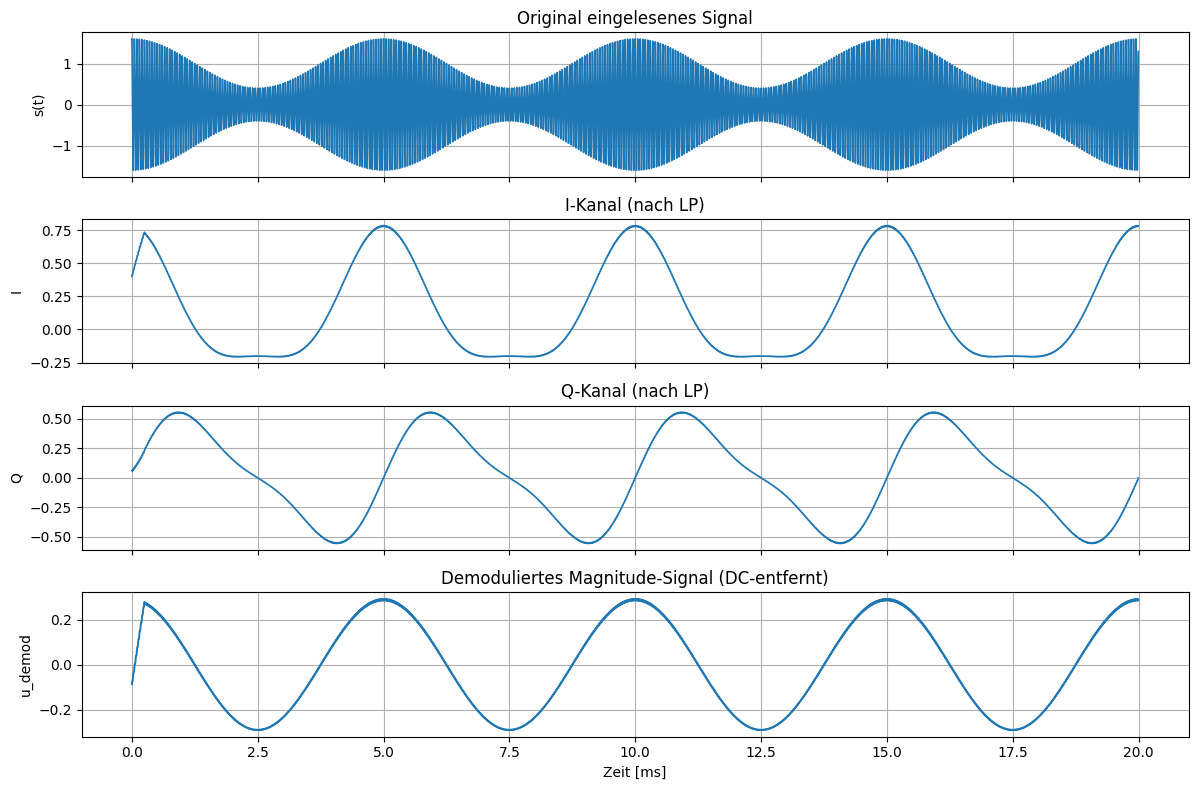

In [4]:
# 3) Zeitbereich: Original + I/Q + Magnitude
t_plot_ms = 20.0
n_plot = min(len(s), int(t_plot_ms * 1e-3 * fs))

fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t[:n_plot]*1e3, s[:n_plot], lw=1.2)
ax[0].set_title('Original eingelesenes Signal')
ax[0].set_ylabel('s(t)')

ax[1].plot(t[:n_plot]*1e3, I[:n_plot], lw=1.2)
ax[1].set_title('I-Kanal (nach LP)')
ax[1].set_ylabel('I')

ax[2].plot(t[:n_plot]*1e3, Q[:n_plot], lw=1.2)
ax[2].set_title('Q-Kanal (nach LP)')
ax[2].set_ylabel('Q')

ax[3].plot(t[:n_plot]*1e3, u_demod[:n_plot], lw=1.4)
ax[3].set_title('Demoduliertes Magnitude-Signal (DC-entfernt)')
ax[3].set_ylabel('u_demod')
ax[3].set_xlabel('Zeit [ms]')

plt.tight_layout()
plt.show()

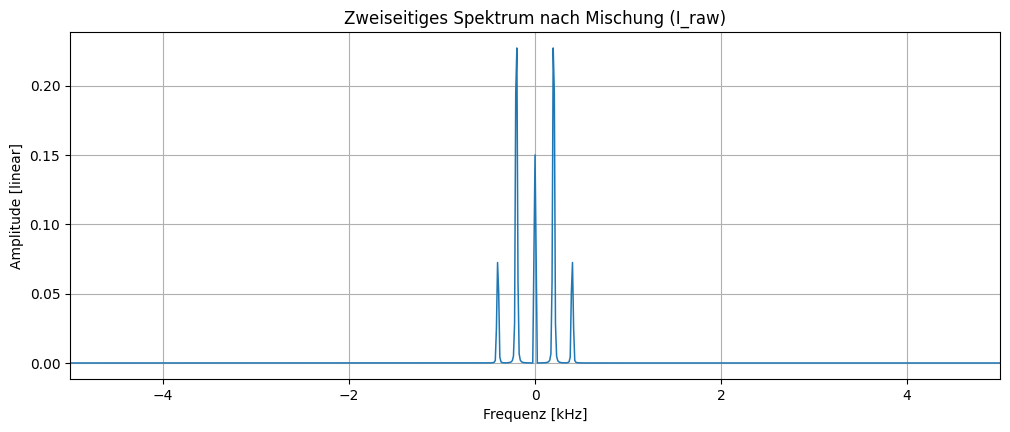

In [5]:
# 4) Zweiseitiges Spektrum der gemischten I-Q-Rohspur (zeigt Frequenzverschiebung nach Low-IF)
N_fft = 16384
x = np.zeros(N_fft)
n_copy = min(len(I_raw), N_fft)
x[:n_copy] = I_raw[:n_copy]

if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w = np.hanning(N_fft)
    elif FFT_WINDOW_KIND == 'hamming':
        w = np.hamming(N_fft)
    else:
        w = np.ones(N_fft)
else:
    w = np.ones(N_fft)

cg = np.mean(w)
X = np.fft.fftshift(np.fft.fft(x * w, n=N_fft))
f = np.fft.fftshift(np.fft.fftfreq(N_fft, d=1/fs))
A = np.abs(X) / (N_fft * max(cg, 1e-12))

plt.figure(figsize=(12, 4.5))
plt.plot(f/1e3, A, lw=1.1)
plt.xlim(-5.0, 5.0)  # um 0 Hz / Low-IF sichtbar
plt.title('Zweiseitiges Spektrum nach Mischung (I_raw)')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [linear]')
plt.show()

In [6]:
# 5) Audioausgabe des demodulierten Signals (48 kS/s, zyklisch wiederholt)
fs_audio = 48_000
duration_s = 4.0

if abs(fs - fs_audio) > 1e-9:
    t_src = np.arange(len(u_demod)) / fs
    n_dst = int(round(len(u_demod) * fs_audio / fs))
    t_dst = np.arange(n_dst) / fs_audio
    u_audio_base = np.interp(t_dst, t_src, u_demod)
else:
    u_audio_base = u_demod.copy()

n_target = int(duration_s * fs_audio)
n_rep = int(np.ceil(n_target / max(1, len(u_audio_base))))
u_audio = np.tile(u_audio_base, n_rep)[:n_target]
u_audio = u_audio / max(1e-12, np.max(np.abs(u_audio)))

print(f'Audio: {len(u_audio)} Samples @ {fs_audio} Hz ({len(u_audio)/fs_audio:.2f} s)')
display(Audio(u_audio, rate=fs_audio))

Audio: 192000 Samples @ 48000 Hz (4.00 s)


In [7]:
# Optional: lokale Wiedergabe über sounddevice
use_sounddevice = False
if use_sounddevice:
    import sounddevice as sd
    sd.play(u_audio.astype(np.float32), fs_audio)
    sd.wait()
    print('Wiedergabe beendet.')